In [ ]:
from torchvision.io import decode_image, read_file
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

In [40]:
import pandas as pd
jsonPath = r"C:\Users\adria\Desktop\Python\Machine-learning\data\imagenet_class_index.json"
image_paths = [
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\348_rock-ptarmigan_fjallripa_lagopus-muta-muta_stekenjokk-jamtland_20110711_1_1000n-336891473.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\blacktail6-2433556291.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\great+white+shark2-494833641.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\OIP-1306616460.jpg",
    r"C:\Users\adria\Desktop\Python\Machine-learning\labb2\data\OIP-2531215737.jpg"
]

class_index = pd.read_json(jsonPath)

In [43]:
#class_index.iloc[class_index[1].str.lower().str.contains("shark")]

class_index = class_index.T
class_index.columns = ["0", "class_name"]

class_index[class_index["class_name"].str.contains("bird")]["class_name"]

94     hummingbird
448      birdhouse
Name: class_name, dtype: str

In [ ]:
def get_model_and_weights(mod="resnet18"):
    weights = get_model_weights(mod).DEFAULT
    model = get_model(mod, weights=weights).eval()
    return model, weights

In [ ]:
def image_prerocess(img_path, weights):
    img_bytes = read_file(img_path)
    img = decode_image(img_bytes)
    
    preprocess = weights.transforms()

    return img, preprocess(img)


In [ ]:
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

def get_activation_map(input_tensor, model):
    cam_extractor = LayerCAM(model, target_layer="layer4")
    out = model(input_tensor.unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)
    return to_pil_image(activation_map[0].squeeze(0), mode="F")


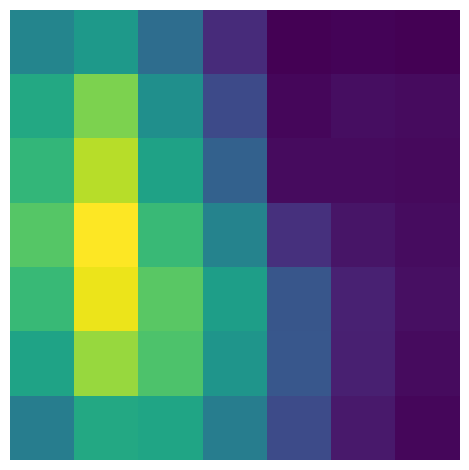

In [53]:
import matplotlib.pyplot as plt

img, input_tensor = image_prerocess(img_path=image_paths[0], weights=weights)

cam_extractor = LayerCAM(model, target_layer="layer4")
out = model(input_tensor.unsqueeze(0))
activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis("off")
plt.tight_layout()
plt.show()

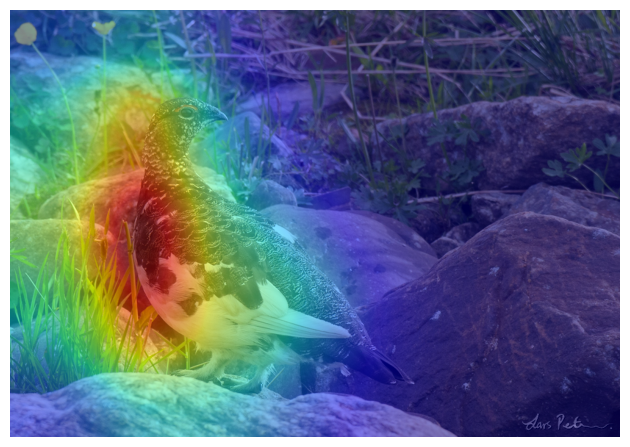

In [ ]:


result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode="F"), alpha=0.5)
plt.imshow(result)
plt.axis("off")
plt.tight_layout()

In [59]:
def get_pred(input_tensor, model):
    prediction = model(input_tensor.unsqueeze(0)).squeeze(0).softmax(0)
    return prediction.detach()

In [57]:
import json

def predict_class(output_tensor, class_indx_path):
    with open(class_indx_path, "r") as file:
        class_index = json.load(file)
    
    probs = output_tensor.squeeze()

    top_index = int(probs.argmax())

    synset_id, class_name = class_index[str(top_index)]

    return {
        "class index" : top_index,
        "class id" : synset_id,
        "class name" : class_name,
        "confidence" : float(probs[top_index])
    }